In [ ]:
# For Google Colab:

# 1. Change the Runtime version to 2025.07 (bottom right -> 'Python 3')
# 2. Run this cell

!git clone https://github.com/hcai-mms/cobis_rs_26.git
%cd cobis_rs_26

%pip install -r requirements_colab.txt


In [1]:
import os
import json
import matplotlib.pyplot as plt 

In [2]:
from helper_files.data_loader_cobi import load_data_cobi as load_data
from helper_files.script_caller import call_script

In [3]:
# create folder with simulation runs
os.makedirs('runs', exist_ok=True)

# Cognitive Biases in Recommender Systems
*Tutorial at RecSys 2026, Minneapolis, United States — September 28, 2026*<br>
*Markus Schedl, Antonela Tommasel, Oleg Lesota*<br>
*Interactive part is based on [Lesota et al. "Oh, Behave! Country Representation Dynamics Created by Feedback Loops in Music Recommender Systems", RecSys'24](https://dl.acm.org/doi/abs/10.1145/3640457.3688187)*

This notebook is a feedback loop simulation playground.<br>
It allows testing cognitive bias/effect-informed user models in the feedback loop simulation setting.

## Feedback loop

We start with a sample of music listening dataset LFM-2b, where **country-of-origin** labels are assigned to both users and items.<br>
At each simulation **iteration** we:
1. Train the model on the model on the current version of the data sample;
2. We produce 10 recommendations to all users;
3. We simulate user consumption with a **choice model**, according to which we add one or more recommendations to the res[ective users' listening histories;
4. With the updated data sample, return to step 1, to start new **iteration**;
   
## Cognitive effects
In this session we will investigate **Postion bias** and **Cultural homophily**. We will use a random choice model as a baseline.

## Simulation setup
In this simplified example every simulation is defined by the following four parameters:
#### 1. Dataset:
- `debug` - smallest available sample, ~ 80 users x 80 items
- `example_timy` - ~ 250 users x 500 items
- `example_small` - ~ 500 users x 1100 items
- `example` - large sample, ~ 10k users x 10k items 

#### 2. Recommenders tested:
- `ItemKNN`
- `BPR`
- `MultiVAE`

#### 4. Number of simulation iterations

#### 5. Choice model
- `rank_based`
- `random`
- `us_centric`
- create custom models from `choice_model_template`

#### 6. RecBole config
- `recbole_config_debug.yaml` 20 epoch cap
- `recbole_config_default.yaml` 200 epoch cap

In [94]:
# Simulation setup

DATASET = 'debug' # debug | example_tiny | example_small | example

MODEL = 'ItemKNN' # ItemKNN | BPR | MultiVAE | ...

N = 5 # number of iterations

CHOICE_MODEL = 'random' # random | rank_based | us_centric | create your own from choice_model_template

RUN_LABEL = '' # additional identifier for the simulation run, optional

CONFIG = 'recbole_config_debug.yaml' # recbole_config_debug.yaml | recbole_config_default.yaml

In [ ]:
# Run simulation
call_script(dataset=DATASET, n=N, model=MODEL, choice_model=CHOICE_MODEL, config=CONFIG)

# Save the run
with open('experiments/'+DATASET+'/params.json') as f:
    d = json.load(f)
    print(d)

run_name = d['dataset_name'] + '--' + d['model'] + '--' + d['choice_model'] + '--' + str(N) + ('--' + RUN_LABEL if len(RUN_LABEL) > 0 else '')
res_folder = 'runs/' + run_name
os.mkdir(res_folder)
os.rename('experiments/'+DATASET+'/params.json', res_folder+'/'+'params.json')
os.rename('experiments/'+DATASET+'/output', res_folder + '/' + 'output')
os.rename('experiments/'+DATASET+'/datasets', res_folder + '/' + 'datasets')


command line args [example 1 --clean --model BPR --choice-model rank_based --config recbole_config_default.yaml] will not be used in RecBole
28 Sep 15:54    INFO  ['main.py', 'example', '1', '--clean', '--model', 'BPR', '--choice-model', 'rank_based', '--config', 'recbole_config_default.yaml']
28 Sep 15:54    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2026
state = INFO
reproducibility = True
data_path = recbole_tmp/dataset
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 200
train_batch_size = 1048576
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'uniform', 'sample_num': 1, 'alpha': 1.0, 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 5
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'RS': [0.75, 

Preparing iteration 1 for dataset/experiment example...
 Done!


Train     0: 100%|████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.22it/s]
28 Sep 15:54    INFO  epoch 0 training [time: 0.84s, train loss: 0.6931]
Evaluate   : 100%|█████████████████████████████████████████████████| 94/94 [00:00<00:00, 161.60it/s]
28 Sep 15:54    INFO  epoch 0 evaluating [time: 0.60s, valid_score: 0.000632]
28 Sep 15:54    INFO  valid result: 
ndcg@10 : 0.000632
28 Sep 15:54    INFO  Saving current: saved/BPR-Sep-28-2026_15-54-16.pth
Train     1: 100%|████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.50it/s]
28 Sep 15:54    INFO  epoch 1 training [time: 0.67s, train loss: 0.6928]
Evaluate   : 100%|█████████████████████████████████████████████████| 94/94 [00:00<00:00, 160.70it/s]
28 Sep 15:54    INFO  epoch 1 evaluating [time: 0.60s, valid_score: 0.000589]
28 Sep 15:54    INFO  valid result: 
ndcg@10 : 0.000589
Train     2: 100%|████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.52it/s]
28 Sep 1

Index(['user_id', 'item_id', 'rank', 'score'], dtype='object')


Applying choice model: 100%|██████████| 10415/10415 [00:03<00:00, 2681.58it/s]


...

Applying choice model: 100%|██████████| 10415/10415 [00:04<00:00, 2601.43it/s]


Iteration 4: Success


command line args [example 5 --clean --model BPR --choice-model rank_based --config recbole_config_default.yaml] will not be used in RecBole
28 Sep 16:16    INFO  ['main.py', 'example', '5', '--clean', '--model', 'BPR', '--choice-model', 'rank_based', '--config', 'recbole_config_default.yaml']
28 Sep 16:16    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2026
state = INFO
reproducibility = True
data_path = recbole_tmp/dataset
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 200
train_batch_size = 1048576
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'uniform', 'sample_num': 1, 'alpha': 1.0, 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 5
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'RS': [0.75, 

Preparing iteration 5 for dataset/experiment example...
 Done!


Train     0: 100%|████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.13s/it]
28 Sep 16:16    INFO  epoch 0 training [time: 1.15s, train loss: 0.6931]
Evaluate   : 100%|███████████████████████████████████████████████| 101/101 [00:00<00:00, 146.87it/s]
28 Sep 16:16    INFO  epoch 0 evaluating [time: 0.71s, valid_score: 0.000769]
28 Sep 16:16    INFO  valid result: 
ndcg@10 : 0.000769
28 Sep 16:16    INFO  Saving current: saved/BPR-Sep-28-2026_16-16-52.pth
Train     1: 100%|████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.09it/s]
28 Sep 16:16    INFO  epoch 1 training [time: 0.92s, train loss: 0.6928]
Evaluate   : 100%|███████████████████████████████████████████████| 101/101 [00:00<00:00, 145.02it/s]
28 Sep 16:16    INFO  epoch 1 evaluating [time: 0.71s, valid_score: 0.000899]
28 Sep 16:16    INFO  valid result: 
ndcg@10 : 0.000899
28 Sep 16:16    INFO  Saving current: saved/BPR-Sep-28-2026_16-16-52.pth
Train     2: 100%|██████████████████

### Check all available runs
The folder `./runs` contains data of all successfully completed runs.<br>
The following cell lists the names of all avalable runs. <br>
Add the runs of interest to the variable `runs` for future analysis (next cell).

In [96]:
# all runs avalable in the 'runs' folder
available_runs = list(filter(lambda x: '--' in x, os.listdir('runs')))
available_runs

['example--ItemKNN--rank_based--5', 'example--BPR--rank_based--5']

In [97]:
runs = available_runs

### Visualize
- `jsd` - bin-per-country miscalibration (jsd(hist, rec))
- `jsd_summarized` - 3-bin country miscalibration (jsd(original_history, current_recommendations), categories: local_other_US)
- `bin_jsd` - 3-bin popularity miscalibration (jsd(original_hist, current_recommendations), categories: low_mid_high)
- `interaction_[jsd/jsd_summarized/jsd_bin]` - same in the evolving user history

---

- `[us/local]_proportion` - proportion of tracks from the country in recommendations
- `interaction_[us/local]_proportion` - proportion of tracks from the country in the evolving history

In [98]:
# Results dictionary
res_dict = dict()

In [99]:
load_runs = runs # runs to process

for run in load_runs:
    if not run in res_dict.keys():
        mdict, udict = load_data(input_dir_path="experiments/"+run.split('--')[0]+"/input", experiments_folder="runs", experiment_name=run, focus_country='US')
        mdf = mdict[list(mdict.keys())[0]]['metrics']
        tmp = mdf[mdf.country == 'global']
        res_dict[run] = tmp


Loading Baselines from CSV File...
Loading Metrics from CSV Files...
Calculating Baselines...
Total items: 10000
Total users: 10415
Total interactions: 229037
Calculating JSD values and recommendation proportions. This may take a while...


Processing Iterations: 100%|██████████████████████████████████████████████████████████████████████████| 5/5 [02:05<00:00, 25.14s/it]


Loaded data successfully


### Visualize local and US proportion evolutions in user profiles

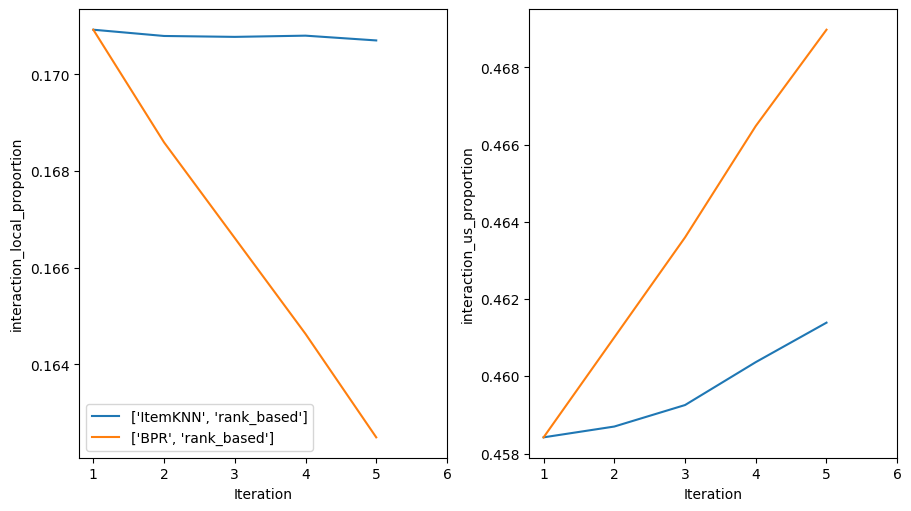

In [102]:
fig, ax = plt.subplots(1, 2, figsize=(9, 5), layout='constrained')
for run in res_dict.keys():
    run_label = run.split('--')[1:3] # 0 - dataset, 1 - recommender, 2 - choice model, 3 - number of iterations
    
    ax[0].plot(res_dict[run].iteration, res_dict[run]['interaction_local_proportion'], label=run_label)
    ax[1].plot(res_dict[run].iteration, res_dict[run]['interaction_us_proportion'], label=run_label)

ax[0].set_xlabel("Iteration")
ax[1].set_xlabel("Iteration")

ax[0].set_xticks(range(1, int(ax[0].get_xticks().max()) + 1))
ax[1].set_xticks(range(1, int(ax[1].get_xticks().max()) + 1))

# ax[0].set_yticks([0, 0.25, 0.5, 0.75, 1])
# ax[1].set_yticks([0, 0.25, 0.5, 0.75, 1])

ax[0].set_ylabel('interaction_local_proportion')
ax[1].set_ylabel('interaction_us_proportion')

ax[0].legend(loc="lower left")
plt.show()

### Visualize country and popularity distributions shift in user profiles (as JSD [0, 1])

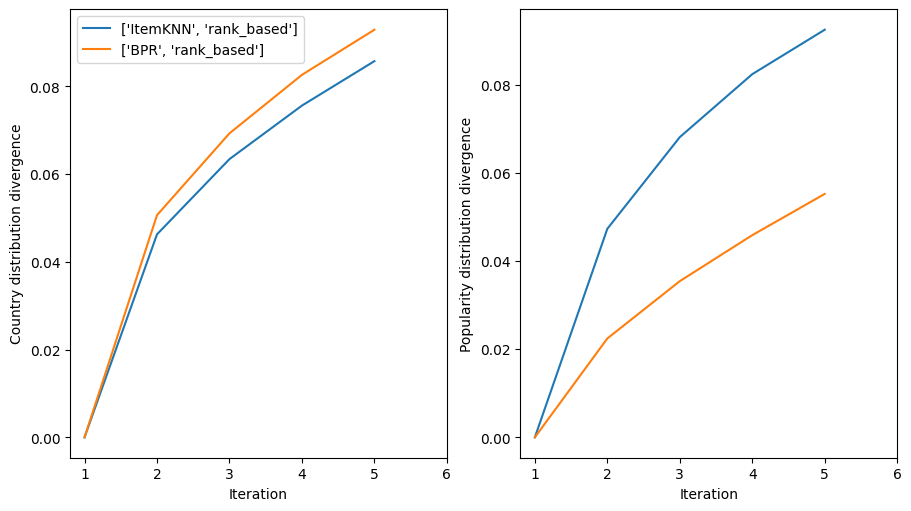

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(9, 5), layout='constrained')
for run in res_dict.keys():
    run_label = run.split('--')[1:3] # 0 - dataset, 1 - recommender, 2 - choice model, 3 - number of iterations
    
    ax[0].plot(res_dict[run].iteration, res_dict[run]['interaction_jsd_summarized'], label=run_label)
    ax[1].plot(res_dict[run].iteration, res_dict[run]['interaction_bin_jsd'], label=run_label)

ax[0].set_xlabel("Iteration")
ax[1].set_xlabel("Iteration")

ax[0].set_xticks(range(1, int(ax[0].get_xticks().max()) + 1))
ax[1].set_xticks(range(1, int(ax[1].get_xticks().max()) + 1))

# ax[0].set_yticks([0, 0.25, 0.5, 0.75, 1])
# ax[1].set_yticks([0, 0.25, 0.5, 0.75, 1])

ax[0].set_ylabel('Country distribution divergence') # 'interaction_jsd_summarized'
ax[1].set_ylabel('Popularity distribution divergence') # 'interaction_bin_jsd'

ax[0].legend(loc="upper left")
plt.show()

### Custom visualization

In [36]:
# visualization setup
visualize_runs = res_dict.keys()
visualize_metric = 'interaction_local_proportion'


Text(0, 0.5, 'interaction_local_proportion')

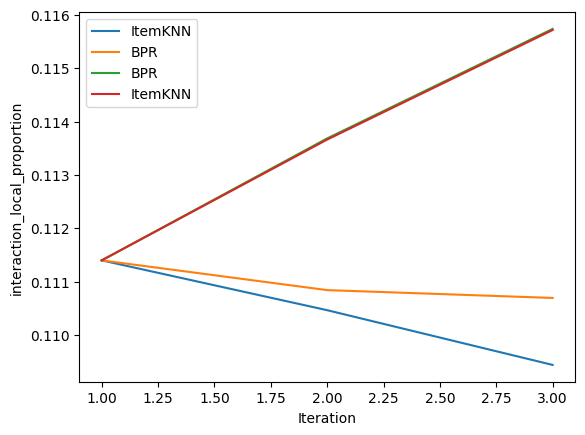

In [37]:
# visualize
for run in visualize_runs:
    run_label = run.split('--')[1] # 0 - dataset, 1 - recommender, 2 - choice model, 3 - number of iterations
    plt.plot(res_dict[run].iteration, res_dict[run][visualize_metric], label=run_label)

plt.legend(loc="upper left")
plt.xlabel("Iteration")
plt.ylabel(visualize_metric)